<h1>Lab 2: Point Cloud classification with Graph Neural Networks</h1>

In [1]:
# (optional) Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = '/content/drive/MyDrive/AdvancedML'

Upload the subset of the ModelNet10 dataset for the lab and unzip it. There will be four files corresponding to the point clouds and class labels for training and testing.

In [3]:
!unzip -o "{dataset_path}/dataset.zip" -d "{dataset_path}"


Archive:  /content/drive/MyDrive/AdvancedML/dataset.zip
  inflating: /content/drive/MyDrive/AdvancedML/test_classes.npy  
  inflating: /content/drive/MyDrive/AdvancedML/test_points.npy  
  inflating: /content/drive/MyDrive/AdvancedML/train_classes.npy  
  inflating: /content/drive/MyDrive/AdvancedML/train_points.npy  


**[TODO]** Import all the python modules you need

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [5]:
# read npy files and print
X_train = np.load(dataset_path + '/train_classes.npy')
y_train = np.load(dataset_path + '/train_points.npy')
X_test = np.load(dataset_path + '/test_classes.npy')
y_test = np.load(dataset_path + '/test_points.npy')
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1281,) (1281, 2048, 3) (200,) (200, 2048, 3)


**[TODO]** Prepare a torch Dataset

In [6]:
class PointCloudDataset(torch.utils.data.Dataset):
    def __init__(self, points_file, classes_file):
        self.points = np.load(points_file)
        self.classes = np.load(classes_file)

    def __len__(self):
        return len(self.points)

    def __getitem__(self, idx):
        return self.points[idx], self.classes[idx]

    def __len__(self):
        return len(self.points)


**[TODO]** Create a torch dataloader instance for training and one for testing

In [7]:
train_dataset = PointCloudDataset(points_file=dataset_path + '/train_points.npy', classes_file=dataset_path + '/train_classes.npy')
test_dataset = PointCloudDataset(points_file=dataset_path + '/test_points.npy', classes_file=dataset_path + '/test_classes.npy')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**[TODO]** Create a function that given a batch of point clouds of size (B,N,3) computes the k-nearest neighbor graph using the Euclidean distance between points and returns its adjacency matrix A of size (B,N,N). Make sure to include self-loops so that all the elements on the diagonal are equal to 1

In [8]:
def create_kNN_graph(batch_points, k):
  """
  Computes the k-nearest neighbor graph for a batch of point clouds.

  Args:
    batch_points: A tensor of shape (B, N, 3) representing a batch of point clouds.
    k: The number of neighbors to consider.

  Returns:
    A tensor of shape (B, N, N) representing the adjacency matrix.
  """

  # extract batch size and number of points
  B, N, _ = batch_points.shape
  # initialize adjacency matrix with zeros : A[b, i, j] = 1 if point j is among the k nearest neighbors of point i, else 0
  A = torch.zeros((B, N, N), device=batch_points.device)
  
  # compute pairwise distances
  dist = torch.cdist(batch_points, batch_points)  # (B, N, N)
  # get indices of k-nearest neighbors (excluding self)
  _, knn_idx = torch.topk(dist, k=k+1, largest=False)

  # set the adjacency matrix entries to 1 for k-nearest neighbors
  for b in range(B):
    for i in range(N):
      A[b, i, knn_idx[b, i]] = 1

  return A

**[TODO]** Create a function that given a batch of adjacency matrices of size (B,N,N) returns a batch of diagonal degree matrices of size (B,N,N)

In [9]:
def create_degree_matrix(batch_adj):
  """
  Computes the diagonal degree matrix for a batch of adjacency matrices.

  Args:
    batch_adj: A tensor of shape (B, N, N) representing a batch of adjacency matrices.

  Returns:
    A tensor of shape (B, N, N) representing the diagonal degree matrix.
  """

  # compute degree for each node
  degree = torch.sum(batch_adj, dim=-1)  # (B, N)
  # create diagonal degree matrix
  D = torch.zeros_like(batch_adj)
  for b in range(batch_adj.shape[0]):
    D[b] = torch.diag(degree[b])

  return D

**[TODO]** Create a torch.nn.Module implementing the GCN graph convolution layer. Do not use the pytorch-geometric library. The layer is provided the adjacency matrix A and the degree matrix D. You can call the Linear layer for the multiplication with the weights matrix. **Be careful with dimensions**: input x will have size (B,N,F'), output will be (B,N,F).

In [10]:
class GCNLayer(torch.nn.Module):
  """
  Graph Convolutional Layer.

  Args:
    in_features: Number of input features.
    out_features: Number of output features.
  """
  def __init__(self, in_features, out_features):
    super(GCNLayer, self).__init__()
    self.linear = torch.nn.Linear(in_features, out_features)

  def forward(self, x, A, D):
    """
    Forward pass of the GCN layer.

    Args:
      x: Input features of shape (B, N, F').
      A: Adjacency matrix of shape (B, N, N).
      D: Degree matrix of shape (B, N, N).

    Returns:
      Output features of shape (B, N, F).
    """

    # core equation : H = D^{-1/2} A D^{-1/2} X W, where:
    # - W is the learnable weight matrix of the linear layer
    # - X is the input feature matrix
    # - A is the adjacency matrix
    # - D is the degree matrix

    # 1) Build D^{-1/2} from the diagonal of D
    # extract the diagonal of D to get the degree of each node
    deg = torch.diagonal(D, dim1=-2, dim2=-1) # (B, N)
    # compute D^{-1/2} by taking the reciprocal of the square root of the degree
    deg_inv_sqrt = torch.pow(deg.clamp(min=1e-12), -0.5)  # avoid division by 0
    # create diagonal matrix D^{-1/2}
    D_inv_sqrt = torch.diag_embed(deg_inv_sqrt) # (B, N, N)

    # 2) Normalize adjacency
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt  # (B, N, N)

    # 3) Linear transform
    x = self.linear(x)  
    # Aggregate features from neighbors
    output = A_norm @ x  # (B, N, F_out)

    return output

**[TODO]** Create a torch.nn.Module with your graph neural network for point cloud classification. Compute the A and D matrices from the input point cloud. Use the GCNLayers you previously defined.

In [11]:
class PointCloudGNN(torch.nn.Module):
    def __init__(self, num_classes, k):
        super(PointCloudGNN, self).__init__()
        self.k = k
        self.num_classes = num_classes

        self.gcn1 = GCNLayer(in_features=3, out_features=64)
        self.gcn2 = GCNLayer(in_features=64, out_features=64)

        self.classifier = torch.nn.Linear(64, num_classes)  # Final classifier layer

    def forward(self, x):
        # Forward pass through the GCN layers
        B, N, _ = x.shape

        # 1) Create kNN graph
        A = create_kNN_graph(x, self.k)  # (B, N, N)
        D = create_degree_matrix(A)       # (B, N, N)

        # 2) First GCN layer
        x = self.gcn1(x, A, D)  # (B, N, 64)
        x = torch.nn.functional.relu(x)

        # 3) Second GCN layer
        x = self.gcn2(x, A, D)  # (B, N, 64)
        x = torch.nn.functional.relu(x)

        # 4) Global average pooling
        # for point cloud classification, we can use a global pooling layer followed by a linear layer to get the final class scores
        x = torch.mean(x, dim=1)  # (B, 64)

        # 5) Final classification layer
        output = self.classifier(x)  # (B, num_classes)

        return output

**[TODO]** Create an instance of your neural network

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gcn_model = PointCloudGNN(num_classes=2, k=20)
gcn_model.to(device)

optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=2e-4)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 20

**[TODO]** Train the network

In [28]:
print(f'Train dataset size: {len(train_dataset)} samples')

Train dataset size: 1281 samples


In [ ]:
epoch_losses = []  # Track loss for each epoch

for epoch in range(num_epochs):
    gcn_model.train()
    total_loss = 0
    for batch_points, batch_labels in train_loader:
        batch_points = batch_points.to(device).float()  # (B, N, 3)
        batch_labels = batch_labels.to(device).long()   # (B,)

        optimizer_gcn.zero_grad()   # reset gradients
        outputs = gcn_model(batch_points)  # (B, num_classes)
        loss = criterion(outputs, batch_labels)
        loss.backward() # compute gradients
        optimizer_gcn.step()    # update parameters

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# save the trained model
torch.save(gcn_model.state_dict(), dataset_path + '/pointcloud_gnn.pth')

Epoch [1/20], Loss: 0.5990
Epoch [2/20], Loss: 0.6199
Epoch [3/20], Loss: 0.5325
Epoch [4/20], Loss: 0.5142
Epoch [5/20], Loss: 0.4313
Epoch [6/20], Loss: 0.4417
Epoch [7/20], Loss: 0.4880
Epoch [8/20], Loss: 0.3898
Epoch [9/20], Loss: 0.3692
Epoch [10/20], Loss: 0.3500
Epoch [11/20], Loss: 0.3381
Epoch [12/20], Loss: 0.3808
Epoch [13/20], Loss: 0.3608
Epoch [14/20], Loss: 0.3166
Epoch [15/20], Loss: 0.4706
Epoch [16/20], Loss: 0.3761
Epoch [17/20], Loss: 0.3405
Epoch [18/20], Loss: 0.2992
Epoch [19/20], Loss: 0.2829
Epoch [20/20], Loss: 0.2716


**[TODO]** Evaluate the network on the test set

In [30]:
print(f'Test dataset size: {len(test_dataset)} samples')

Test dataset size: 200 samples


In [14]:
# load the model for evaluation
gcn_model.load_state_dict(torch.load(dataset_path + '/pointcloud_gnn.pth'))

with torch.no_grad():  # disable gradient computation for evaluation
    gcn_model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_probs = []
    
    for batch_points, batch_labels in test_loader:
        batch_points = batch_points.to(device).float()  # (B, N, 3)
        batch_labels = batch_labels.to(device).long()   # (B,)

        outputs = gcn_model(batch_points)  # (B, num_classes)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)  # get predicted class
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 99.00%


## Model Analysis and Visualization

Import visualization libraries and create comprehensive plots to understand model performance.

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

Show the image and its predicted class for a random sample from the test dataset.

Ground truth label: Chair, Predicted label: Chair


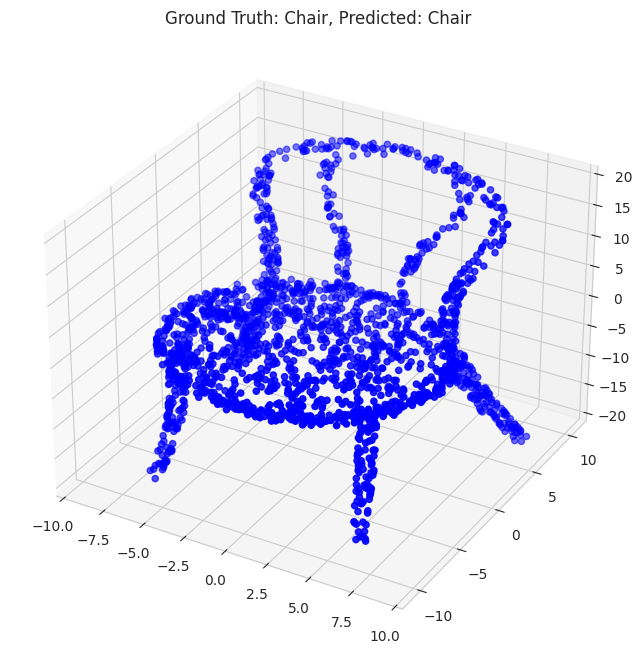

In [38]:
import random

class_names = {0: 'Chair', 1: 'Table'}

# select a random sample from the test dataset
idx = random.randint(0, len(test_dataset) - 1)
points, label = test_dataset[idx]
label = label.item()  # convert tensor to scalar
label_name = class_names[label]
predicted_label = all_predictions[idx]
predicted_label_name = class_names[predicted_label]
print(f'Ground truth label: {label_name}, Predicted label: {predicted_label_name}')
# visualize the point cloud
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='b', marker='o')
ax.set_title(f'Ground Truth: {label_name}, Predicted: {predicted_label_name}')
plt.show()

### Training Loss Curve

Visualize how the loss evolves during training to identify overfitting or convergence issues.

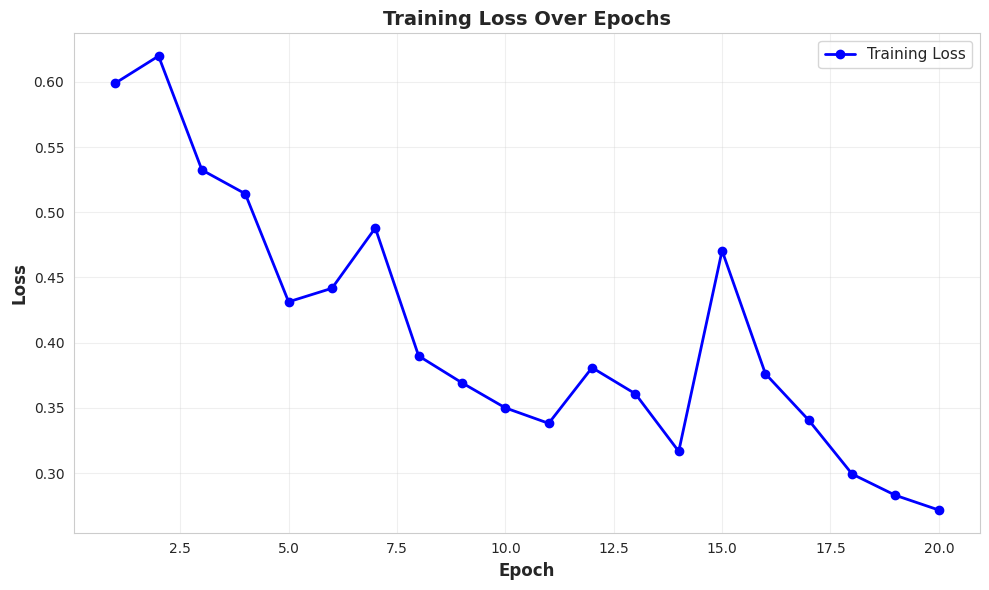

Initial Loss: 0.5990
Final Loss: 0.2716
Loss Reduction: 54.66%


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, 'b-o', linewidth=2, markersize=6, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {epoch_losses[0]:.4f}")
print(f"Final Loss: {epoch_losses[-1]:.4f}")
print(f"Loss Reduction: {((epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100):.2f}%")

### Confusion Matrix

Shows the performance breakdown by class - true positives, false positives, etc.

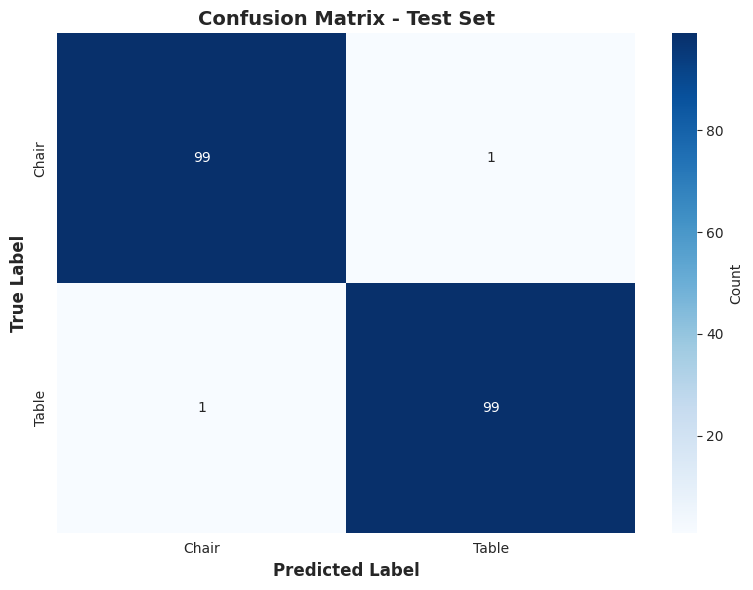


Confusion Matrix:
[[99  1]
 [ 1 99]]

True Negatives (TN): 99
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 99


In [39]:
cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['Chair', 'Table'],
            yticklabels=['Chair', 'Table'],
            cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

Number of wrong predictions: 2
Sample 1: Ground Truth: Chair, Predicted: Table


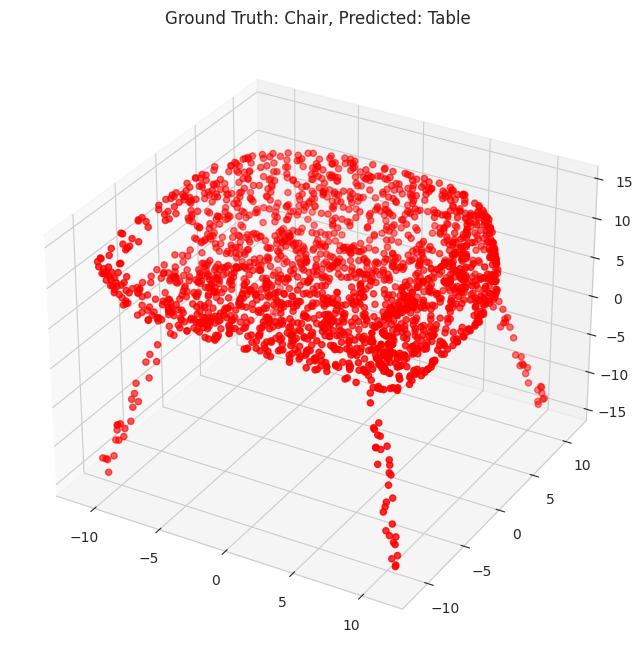

Sample 2: Ground Truth: Table, Predicted: Chair


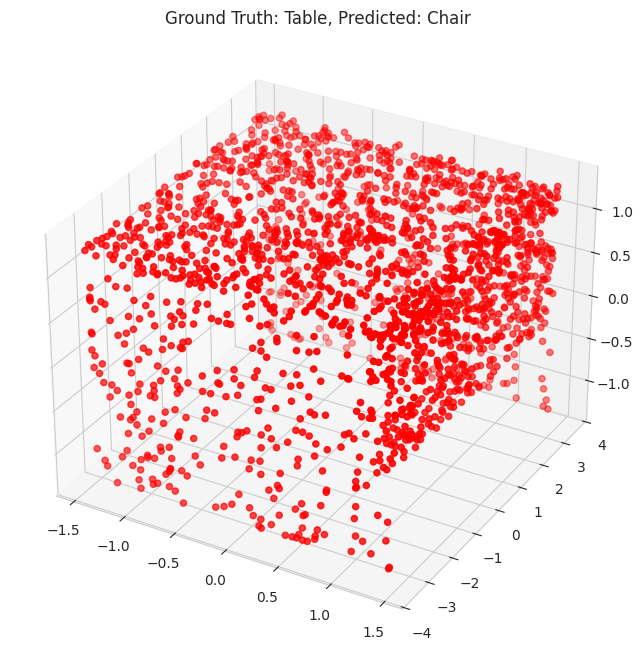

In [40]:
# extract the images with wrong predictions
wrong_indices = np.where(all_predictions != all_labels)[0]
print(f"Number of wrong predictions: {len(wrong_indices)}")

# show the first 5 wrong predictions
for i in range(min(5, len(wrong_indices))):
    idx = wrong_indices[i]
    points, label = test_dataset[idx]
    label = label.item()  # convert tensor to scalar
    label_name = class_names[label]
    predicted_label = all_predictions[idx]
    predicted_label_name = class_names[predicted_label]
    print(f"Sample {i+1}: Ground Truth: {label_name}, Predicted: {predicted_label_name}")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='r', marker='o')
    ax.set_title(f'Ground Truth: {label_name}, Predicted: {predicted_label_name}')
    plt.show()

### Prediction Confidence Distribution

Analyze model confidence levels - how certain is the model about its predictions?

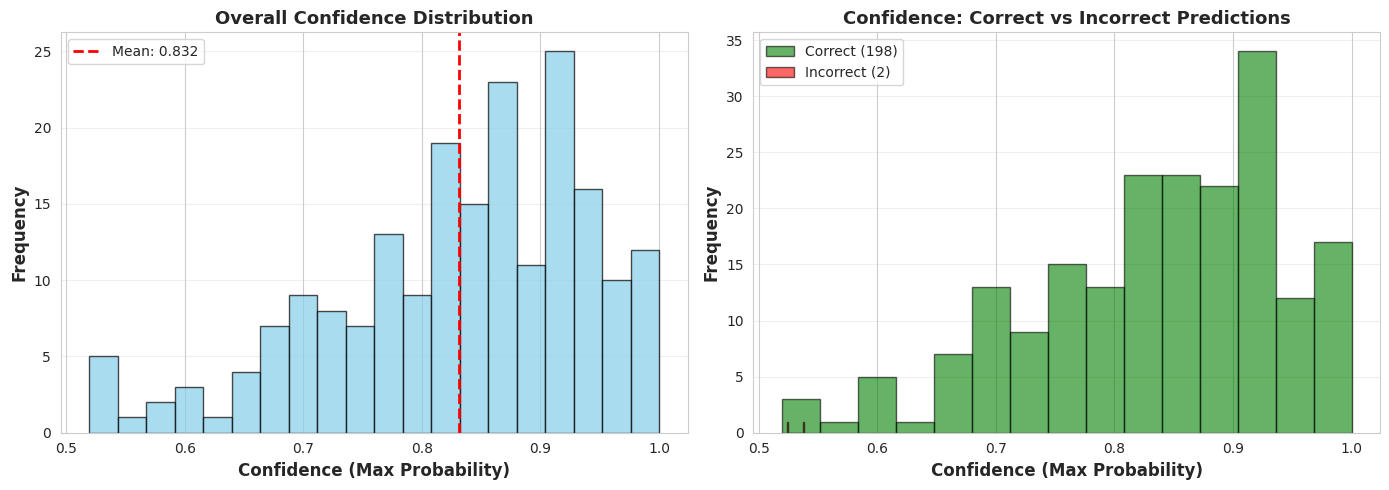


Confidence Statistics:
Mean Confidence: 0.8317
Min Confidence: 0.5195
Max Confidence: 1.0000
Std Confidence: 0.1103

Mean confidence for correct predictions: 0.8347
Mean confidence for incorrect predictions: 0.5309


In [27]:
# Extract max probability (confidence) for each prediction
max_probs = np.max(all_probs, axis=1)
correct_mask = (all_predictions == all_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
ax1.hist(max_probs, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(np.mean(max_probs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(max_probs):.3f}')
ax1.set_xlabel('Confidence (Max Probability)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Overall Confidence Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Correct vs Incorrect predictions
correct_probs = max_probs[correct_mask]
incorrect_probs = max_probs[~correct_mask]

ax2.hist(correct_probs, bins=15, alpha=0.6, label=f'Correct ({len(correct_probs)})', color='green', edgecolor='black')
if len(incorrect_probs) > 0:
    ax2.hist(incorrect_probs, bins=15, alpha=0.6, label=f'Incorrect ({len(incorrect_probs)})', color='red', edgecolor='black')
ax2.set_xlabel('Confidence (Max Probability)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Confidence: Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nConfidence Statistics:")
print(f"Mean Confidence: {np.mean(max_probs):.4f}")
print(f"Min Confidence: {np.min(max_probs):.4f}")
print(f"Max Confidence: {np.max(max_probs):.4f}")
print(f"Std Confidence: {np.std(max_probs):.4f}")
if len(incorrect_probs) > 0:
    print(f"\nMean confidence for correct predictions: {np.mean(correct_probs):.4f}")
    print(f"Mean confidence for incorrect predictions: {np.mean(incorrect_probs):.4f}")